In [1]:
import glob
from utilities import utils
from tasks import cmj

[assemble_jumps] dropped (rep count != 3 somewhere): ['P11', 'P17']
[assemble_jumps] dropped (rep count != 3 somewhere): ['P11', 'P17']


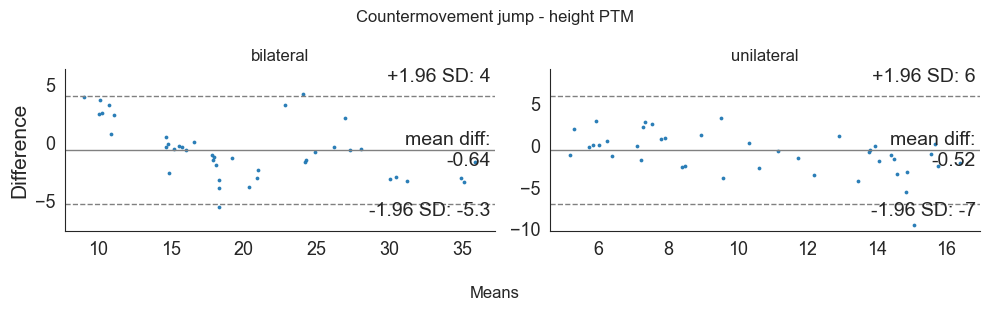

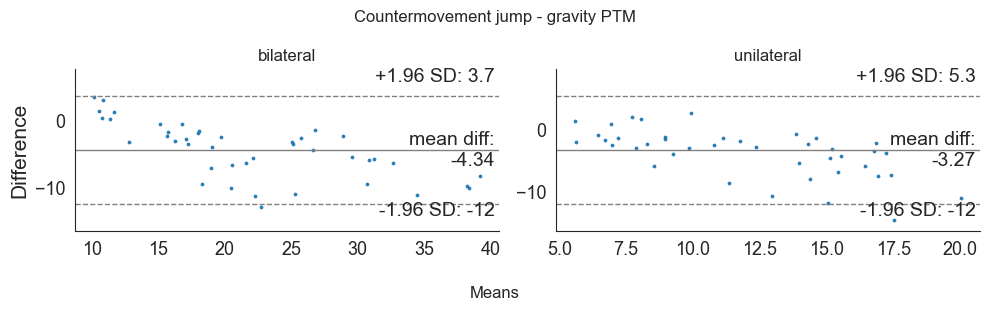

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Jump height,CMJ bilateral,height,Force plates,2.05,0.96,0.95
1,Jump height,CMJ unilateral,height,Force plates,2.23,0.83,0.65


In [2]:
import glob
from utilities import utils
from tasks import cmj

bl_files = sorted(p for p in glob.glob("data/keypoints/cmj/*.txt")
                  if "world" not in p.lower() and "UL" not in p.upper())
ul_files = sorted(p for p in glob.glob("data/keypoints/cmj/*.txt")
                  if "world" not in p.lower() and "UL" in p.upper())
subjects = utils.read_list('cmj_data')

all_jumps_df_ptmh = cmj.assemble_jumps(bl_files, ul_files, subjects, ptm='height')
all_jumps_df_ptmg = cmj.assemble_jumps(bl_files, ul_files, subjects, ptm='gravity')

# from here your uploaded notebook runs unchanged:
cmj.ba_plots(all_jumps_df_ptmh, title='height PTM')
cmj.ba_plots(all_jumps_df_ptmg, title='gravity PTM')
results_df_h = cmj.get_metrics(all_jumps_df_ptmh, ptm='height')
results_df_g = cmj.get_metrics(all_jumps_df_ptmg, ptm='gravity')
results_df_h

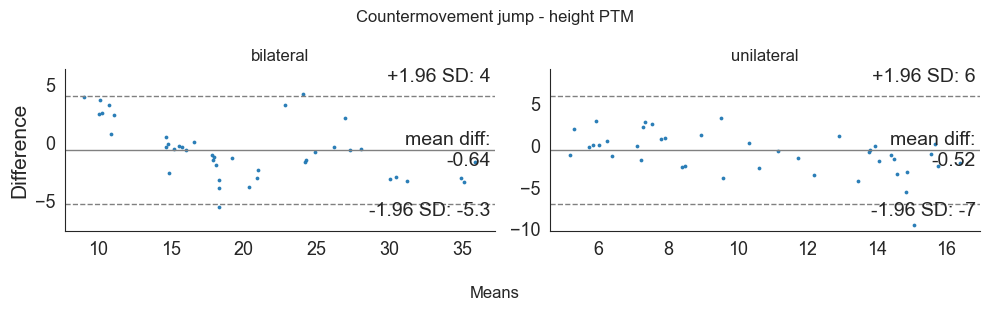

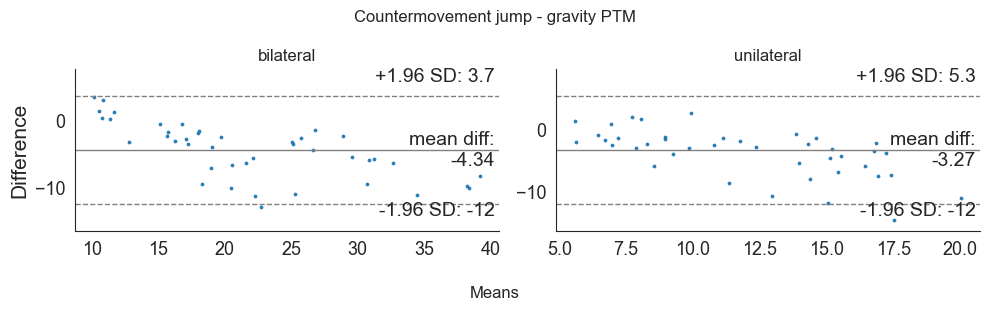

In [3]:
cmj.get_metrics(all_jumps_df_ptmg, ptm='gravity')
cmj.ba_plots(all_jumps_df_ptmh, title='height PTM')
cmj.ba_plots(all_jumps_df_ptmg, title='gravity PTM')

In [4]:
import utils                    # does bare import work?
import utilities.utils          # or is it under utilities?
import utilities.PTM

ModuleNotFoundError: No module named 'utils'

In [ ]:
import sys, os
print("cwd:", os.getcwd())
print("utilities on path?")
import importlib.util
for name in ["utils", "utilities", "utilities.utils", "utilities.PTM", "PTM"]:
    spec = importlib.util.find_spec(name)
    print(f"  {name:18} -> {spec.origin if spec else 'NOT FOUND'}")

cwd: c:\Users\dylan\Documents\Projects\machine_vision_media_pipe
utilities on path?
  utils              -> NOT FOUND
  utilities          -> None
  utilities.utils    -> c:\Users\dylan\Documents\Projects\machine_vision_media_pipe\utilities\utils.py
  utilities.PTM      -> c:\Users\dylan\Documents\Projects\machine_vision_media_pipe\utilities\PTM.py
  PTM                -> NOT FOUND


In [ ]:
from tasks import cmj
print("PTM module:", cmj.PTM)            # should print the utilities/PTM.py module
print("utils module:", cmj.utils)        # should print utilities/utils.py

PTM module: <module 'utilities.PTM' from 'c:\\Users\\dylan\\Documents\\Projects\\machine_vision_media_pipe\\utilities\\PTM.py'>
utils module: <module 'utilities.utils' from 'c:\\Users\\dylan\\Documents\\Projects\\machine_vision_media_pipe\\utilities\\utils.py'>


In [ ]:
all_jumps_df_ptmh = cmj.assemble_jumps(bl_files, ul_files, subjects, ptm='height')
all_jumps_df_ptmg = cmj.assemble_jumps(bl_files, ul_files, subjects, ptm='gravity')
print(len(all_jumps_df_ptmh), "height /", len(all_jumps_df_ptmg), "gravity subjects")
cmj.get_metrics(all_jumps_df_ptmh, ptm='height')

NameError: name 'bl_files' is not defined

[assemble_jumps] dropped (rep count != 3 somewhere): ['P11', 'P17']
[assemble_jumps] dropped (rep count != 3 somewhere): ['P11', 'P17']


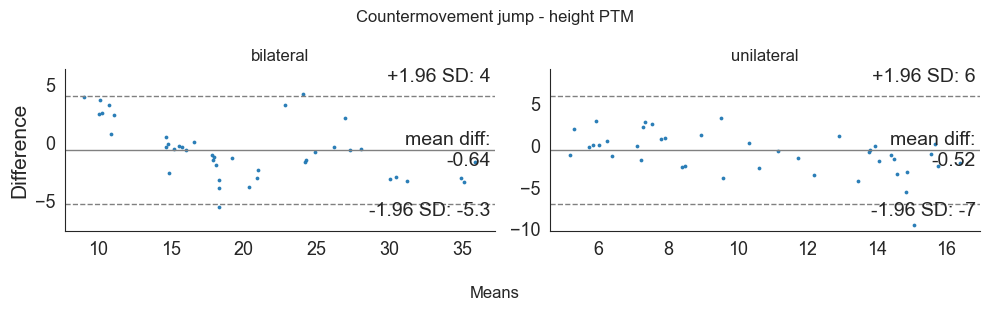

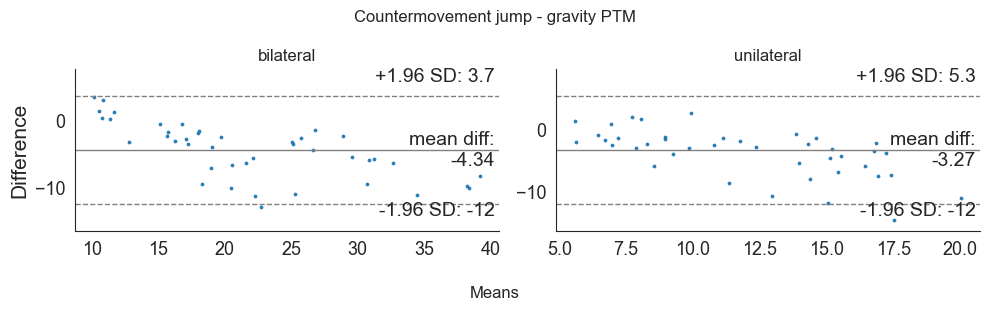

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Jump height,CMJ bilateral,height,Force plates,2.05,0.96,0.95
1,Jump height,CMJ unilateral,height,Force plates,2.23,0.83,0.65


In [ ]:
import glob
from utilities import utils
from tasks import cmj

bl_files = sorted(p for p in glob.glob("data/keypoints/cmj/*.txt")
                  if "world" not in p.lower() and "UL" not in p.upper())
ul_files = sorted(p for p in glob.glob("data/keypoints/cmj/*.txt")
                  if "world" not in p.lower() and "UL" in p.upper())
subjects = utils.read_list('cmj_data')

all_jumps_df_ptmh = cmj.assemble_jumps(bl_files, ul_files, subjects, ptm='height')
all_jumps_df_ptmg = cmj.assemble_jumps(bl_files, ul_files, subjects, ptm='gravity')

# from here your uploaded notebook runs unchanged:
cmj.ba_plots(all_jumps_df_ptmh, title='height PTM')
cmj.ba_plots(all_jumps_df_ptmg, title='gravity PTM')
results_df_h = cmj.get_metrics(all_jumps_df_ptmh, ptm='height')
results_df_g = cmj.get_metrics(all_jumps_df_ptmg, ptm='gravity')
results_df_h

In [ ]:
import pandas as pd

results_df_h = cmj.get_metrics(all_jumps_df_ptmh, ptm='height')
results_df_g = cmj.get_metrics(all_jumps_df_ptmg, ptm='gravity')

cmj_table = pd.concat([results_df_g, results_df_h], ignore_index=True)
cmj_table = cmj_table.sort_values(['Task', 'PTM Ref']).reset_index(drop=True)
cmj_table

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Jump height,CMJ bilateral,gravity,Force plates,4.85,0.92,0.77
1,Jump height,CMJ bilateral,height,Force plates,2.05,0.96,0.95
2,Jump height,CMJ unilateral,gravity,Force plates,4.25,0.72,0.42
3,Jump height,CMJ unilateral,height,Force plates,2.23,0.83,0.65


In [ ]:
cmj_table.set_index(['Metric', 'Task', 'PTM Ref'])

Ground Truth   MAE  Reliability   ICC
Metric      Task           PTM Ref                                       
Jump height CMJ bilateral  gravity  Force plates  4.85         0.92  0.77
                           height   Force plates  2.05         0.96  0.95
            CMJ unilateral gravity  Force plates  4.25         0.72  0.42
                           height   Force plates  2.23         0.83  0.65

In [ ]:
from tasks import cmj

for sid in ["P11", "P17"]:
    for files, label in [(bl_files, "bl"), (ul_files, "ul")]:
        fp = next((p for p in files if sid in p), None)
        if fp:
            r = cmj.calculate_cmj(fp)
            print(f"{sid} {label}: {r['reps']} reps   ({fp.split(chr(92))[-1]})")

P11 bl: 3 reps   (P11_CMJ_BL_FRONT.txt)
P11 ul: 4 reps   (P11_CMJ_UL_FRONT.txt)
P17 bl: 3 reps   (P17_CMJ_BL_FRONT.txt)
P17 ul: 4 reps   (P17_CMJ_UL_FRONT.txt)


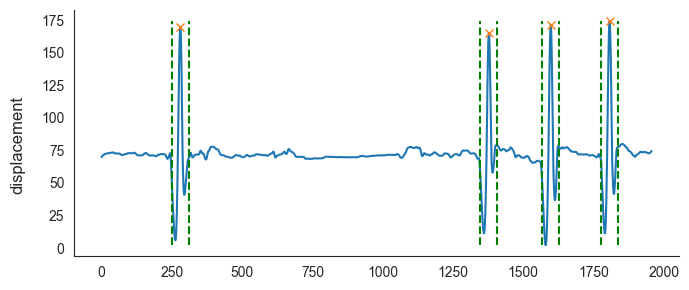

found 4 reps


In [ ]:
import numpy as np
#from unilities import utils
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

fp = next(p for p in ul_files if "P17" in p)   # adjust sid/task to the culprit from above
df = cmj.load_pose_file(fp); px = cmj.to_pixels(df, 1920, 1080)
hip = np.column_stack([(px["LEFT_HIP_x"]+px["RIGHT_HIP_x"])/2,
                       (px["LEFT_HIP_y"]+px["RIGHT_HIP_y"])/2])
hip_y = savgol_filter(utils.flip_axis(hip.copy())[:,1], 11, 2)

# plot the whole signal with peaks marked
segs, reps = utils.get_reps(hip_y, fps=30, rewind=1, forward=1, d=5,
                            expected_reps=3, plot_peaks=True)
plt.show()
print("found", len(reps), "reps")

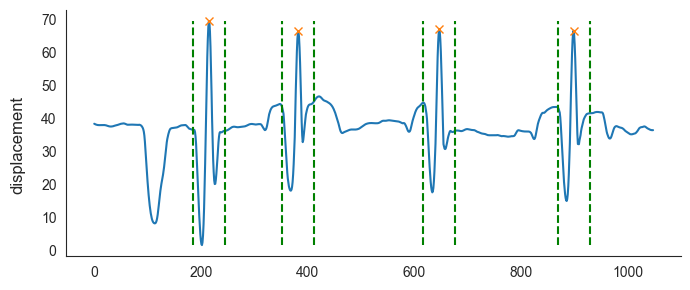

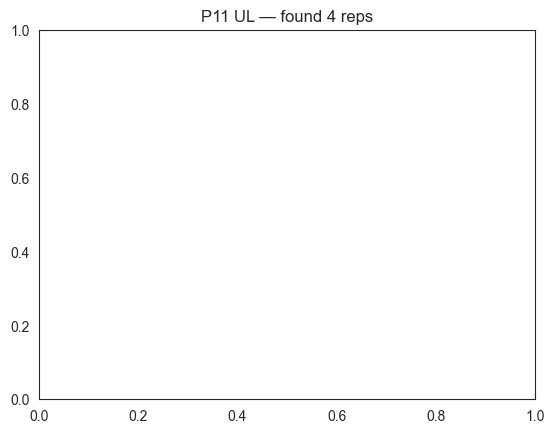

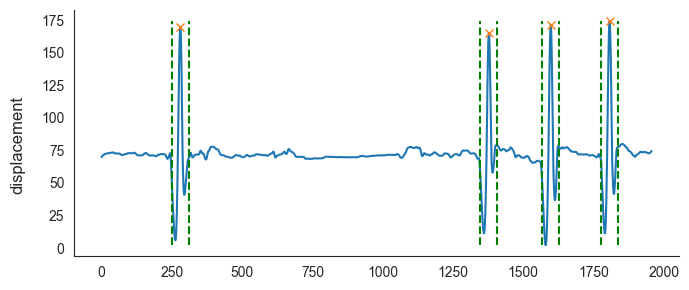

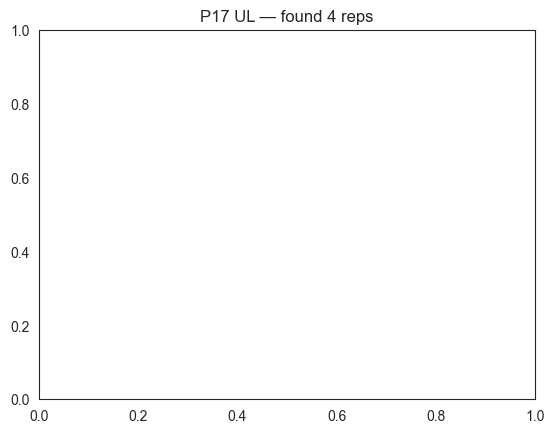

In [ ]:


for sid in ["P11", "P17"]:
    fp = next(p for p in ul_files if sid in p)
    df = cmj.load_pose_file(fp); px = cmj.to_pixels(df, 1920, 1080)
    hip = np.column_stack([(px["LEFT_HIP_x"]+px["RIGHT_HIP_x"])/2,
                           (px["LEFT_HIP_y"]+px["RIGHT_HIP_y"])/2])
    hip_y = savgol_filter(utils.flip_axis(hip.copy())[:,1], 11, 2)
    segs, reps = utils.get_reps(hip_y, fps=30, rewind=1, forward=1, d=5,
                                expected_reps=3, plot_peaks=True)
    plt.title(f"{sid} UL — found {len(reps)} reps")
    plt.show()

In [ ]:
fp_heights = cmj._fp_heights_by_subject(subjects)
for sid in ["P11", "P17"]:
    fpath = next(p for p in ul_files if sid in p)
    r = cmj.calculate_cmj(fpath)
    # build all 4 MMC heights under height scaling
    scale = r["scale_height"]
    mmc4 = [round(cmj.ts_jump_height(j*scale, fps=30),2) for j in r["_jumps"]]
    print(sid, "force(3):", fp_heights[sid]["ul"])
    print(sid, "mmc(4):  ", mmc4)
    print(sid, "drop first ->", mmc4[1:], " | drop last ->", mmc4[:3])
    print()

P11 force(3): [6.83, 7.78, 7.12]
P11 mmc(4):   [np.float64(15.96), np.float64(11.0), np.float64(12.18), np.float64(11.15)]
P11 drop first -> [np.float64(11.0), np.float64(12.18), np.float64(11.15)]  | drop last -> [np.float64(15.96), np.float64(11.0), np.float64(12.18)]

P17 force(3): [19.81, 21.42, 22.77]
P17 mmc(4):   [np.float64(26.03), np.float64(22.1), np.float64(23.69), np.float64(25.22)]
P17 drop first -> [np.float64(22.1), np.float64(23.69), np.float64(25.22)]  | drop last -> [np.float64(26.03), np.float64(22.1), np.float64(23.69)]



In [ ]:
fp = next(p for p in ul_files if "P11" in p)
df = cmj.load_pose_file(fp); px = cmj.to_pixels(df, 1920, 1080)
rest_n = int(0.5 * 30)   # 15 frames
print("pixel body height (P11):", cmj.pixel_body_height(px, rest_n))
print("frame height fraction:", cmj.pixel_body_height(px, rest_n)/1080)
# compare to a clean subject, e.g. P03:
fp3 = next(p for p in ul_files if "P03" in p)
df3 = cmj.load_pose_file(fp3); px3 = cmj.to_pixels(df3, 1920, 1080)
print("pixel body height (P03):", cmj.pixel_body_height(px3, rest_n))

pixel body height (P11): 384.1753379390355
frame height fraction: 0.3557179054991069
pixel body height (P03): 399.2558215706379


In [ ]:
import numpy as np
fp = next(p for p in ul_files if "P11" in p)
r = cmj.calculate_cmj(fp)
print("P11 scale_height:", round(r["scale_height"],3), "mm/px")
for i, j in enumerate(r["_jumps"]):
    peak_px = j.max()
    print(f"rep {i}: toe peak {peak_px:.1f} px  -> {peak_px*r['scale_height']:.1f} mm  -> height {cmj.ts_jump_height(j*r['scale_height'], fps=30):.1f} cm")

P11 scale_height: 4.685 mm/px
rep 0: toe peak 37.0 px  -> 173.5 mm  -> height 16.0 cm
rep 1: toe peak 24.8 px  -> 116.2 mm  -> height 11.0 cm
rep 2: toe peak 31.1 px  -> 145.8 mm  -> height 12.2 cm
rep 3: toe peak 24.7 px  -> 115.7 mm  -> height 11.2 cm


In [ ]:
for sid in ["P11", "P17"]:
    fp = next(p for p in ul_files if sid in p)
    df = cmj.load_pose_file(fp); px = cmj.to_pixels(df, 1920, 1080)
    hip = np.column_stack([(px["LEFT_HIP_x"]+px["RIGHT_HIP_x"])/2,
                           (px["LEFT_HIP_y"]+px["RIGHT_HIP_y"])/2])
    hip_y = savgol_filter(utils.flip_axis(hip.copy())[:,1], 11, 2)
    segs, reps = utils.get_reps(hip_y, fps=30, rewind=1, forward=1, d=5, expected_reps=3)
    peaks = [round(float(np.asarray(r).max()),1) for r in reps]
    print(sid, "peak amplitudes:", peaks)

P11 peak amplitudes: [69.6, 66.5, 67.1, 66.7]
P17 peak amplitudes: [169.9, 165.0, 171.5, 174.3]


In [5]:
# P17: drop-first works (aligns with force plates). P11: your call.
all_jumps_df_ptmh = cmj.assemble_jumps(bl_files, ul_files, subjects, ptm='height',
                                       trim_first_ul={'P17', 'P11'})
all_jumps_df_ptmg = cmj.assemble_jumps(bl_files, ul_files, subjects, ptm='gravity',
                                       trim_first_ul={'P17', 'P11'})
print(len(all_jumps_df_ptmh), "subjects")        # should now be 16
cmj.get_metrics(all_jumps_df_ptmh, ptm='height')

16 subjects


,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Jump height,CMJ bilateral,height,Force plates,2.52,0.98,0.95
1,Jump height,CMJ unilateral,height,Force plates,2.36,0.88,0.76


In [6]:
print("BL without P11/P17:",
      cmj.get_metrics(all_jumps_df_ptmh.drop(['P11','P17']), ptm='height').iloc[0]['MAE'])

BL without P11/P17: 2.05


In [ ]:
import pandas as pd

def cohort_table(df_h, df_g, label):
    t = pd.concat([cmj.get_metrics(df_g, ptm='gravity'),
                   cmj.get_metrics(df_h, ptm='height')], ignore_index=True)
    t = t.sort_values(['Task', 'PTM Ref']).reset_index(drop=True)
    t.insert(0, 'Cohort', label)
    return t

full   = cohort_table(all_jumps_df_ptmh, all_jumps_df_ptmg, 'All 16')
subset = cohort_table(all_jumps_df_ptmh.drop(['P11','P17']),
                      all_jumps_df_ptmg.drop(['P11','P17']), 'Excl. P11/P17')

comparison = pd.concat([full, subset], ignore_index=True)
comparison = comparison.sort_values(['Task', 'PTM Ref', 'Cohort'])
comparison.set_index(['Task', 'PTM Ref', 'Cohort'])

Metric  Ground Truth   MAE  \
Task           PTM Ref Cohort                                           
CMJ bilateral  gravity All 16         Jump height  Force plates  6.21   
                       Excl. P11/P17  Jump height  Force plates  4.85   
               height  All 16         Jump height  Force plates  2.52   
                       Excl. P11/P17  Jump height  Force plates  2.05   
CMJ unilateral gravity All 16         Jump height  Force plates  5.05   
                       Excl. P11/P17  Jump height  Force plates  4.25   
               height  All 16         Jump height  Force plates  2.36   
                       Excl. P11/P17  Jump height  Force plates  2.23   

                                      Reliability   ICC  
Task           PTM Ref Cohort                            
CMJ bilateral  gravity All 16                0.97  0.77  
                       Excl. P11/P17         0.92  0.77  
               height  All 16                0.98  0.95  
                       Excl. P11/P17         0.96  0.95  
CMJ unilateral gravity All 16                0.84  0.53  
                       Excl. P11/P17         0.72  0.42  
               height  All 16                0.88  0.76  
                       Excl. P11/P17         0.83  0.65

: 